# 03-TinyML Toolchains for Microcontrollers (Edge Impulse)

Lesson 02 measured compression against a target we never actually pinned down: "smaller" relative to a 32-bit float baseline, running on a device with enough RAM and a full operating system to host the TensorFlow Lite interpreter. That target — a phone, a Raspberry Pi, a Jetson — is generous compared to where **TinyML** actually lives: a microcontroller unit (MCU) with tens to a few hundred kilobytes of RAM, no filesystem, no OS scheduler, and a CPU clocked in tens of megahertz rather than gigahertz. A compressed model that comfortably fits a phone can still be catastrophically too large for an MCU, and the standard TensorFlow Lite Python interpreter cannot even run there — it depends on dynamic memory allocation, threading, and a runtime footprint the MCU simply does not have.

This is the gap the TinyML toolchain closes. The workflow is fundamentally different from cloud or mobile deployment: instead of shipping a `.tflite` file to a device that already has a capable interpreter installed, the entire inference engine must be *cross-compiled into the firmware itself*, with every buffer statically sized at build time because there is no heap to allocate from at runtime. We will use **Edge Impulse**, the standard end-to-end platform for this workflow — data collection from real sensors, DSP feature extraction, model training, and C++ library export — and dig into the memory-arena planning problem that makes MCU deployment a fundamentally different engineering discipline from server or mobile inference.

## 1. The Mathematics of Static Memory Planning

### The Two Hard Ceilings: Flash and RAM

An MCU deployment is constrained by two independent, non-fungible memory budgets. **Flash** (ROM) stores the immutable model weights and the compiled interpreter/kernel code:

$$B_{flash} = B_{weights} + B_{code} \le C_{flash}$$

**RAM** stores the mutable *activation tensors* produced while the network executes — inputs, intermediate outputs, and outputs — inside a single fixed-size buffer called the **tensor arena**:

$$B_{arena} \le C_{ram}$$

Crucially, $B_{arena}$ is **not** the sum of every activation tensor in the network. A tensor is only "alive" between the operation that produces it and the last operation that consumes it; once consumed, its memory can be reused by a later tensor. This is the central optimization problem of embedded inference runtimes like TensorFlow Lite Micro.

### Tensor Lifetimes and the Interval Scheduling Problem

Model each activation tensor $t_i$ as an interval $[s_i, e_i]$ over operator execution order — allocated at op $s_i$, last read at op $e_i$ — with byte size $b_i$. Two tensors *conflict* (cannot share memory) if their intervals overlap: $[s_i, e_i] \cap [s_j, e_j] \neq \varnothing$. The minimum arena size is the solution to an **interval graph coloring / peak-memory scheduling** problem:

$$B_{arena}^{\star} = \max_{k} \sum_{i \,:\, s_i \le k \le e_i} b_i$$

— the largest total size of all tensors simultaneously alive at any single operator step $k$. This is provably far smaller than the naive upper bound $\sum_i b_i$ (summing every tensor ever created) whenever the network is a chain or shallow DAG, because most tensors die almost immediately after being consumed by the next layer. A practical greedy allocator achieves near-optimal packing by processing tensors in order of decreasing size and placing each at the lowest free byte-offset that doesn't collide with any tensor whose interval overlaps it — the same first-fit-decreasing heuristic used in general-purpose memory allocators.

### Fixed-Point Compute and Cycles-per-MAC

MCUs targeted by TinyML rarely have a hardware floating-point unit efficient enough for dense inference, which is *why* INT8 quantization (Lesson 02) is not optional here — it's required. Optimized kernel libraries (e.g. **CMSIS-NN** for ARM Cortex-M) execute quantized multiply-accumulates (MACs) in a small, hardware-dependent number of cycles $\kappa$ per MAC. Estimated inference latency at clock frequency $f_{clk}$ is:

$$T_{infer} \approx \frac{N_{MACs} \cdot \kappa}{f_{clk}}$$

For a Cortex-M4F with CMSIS-NN, $\kappa$ is typically in the range of $1$–$4$ cycles/MAC depending on SIMD utilization — this single ratio is what an Edge Impulse "Performance Calibration" report is estimating when it predicts on-device latency before you ever flash real hardware.

## 2. Imperative Execution: Static Arena Planning for a Keyword-Spotting Model

We will define a small quantized model's per-layer activation tensors and their operator-order lifetimes (representative of a keyword-spotting MFCC classifier — a canonical Edge Impulse tutorial project), implement the greedy interval-scheduling arena allocator directly from the math above, and compare it against the naive "sum everything" upper bound.

In [1]:
# Required installations: pip install tensorflow edgeimpulse numpy
import numpy as np
import tensorflow as tf

print("--- 🚀 Initializing TinyML Toolchain Sandbox (Edge Impulse) ---")

tf.random.set_seed(3)
np.random.seed(3)

# 1. 📝 Build and INT8-quantize a small keyword-spotting classifier (13 MFCC coeffs x 16 frames -> 4 keywords)
N_MFCC, N_FRAMES, N_CLASSES = 13, 16, 4
X_train = np.random.randn(500, N_MFCC * N_FRAMES).astype("float32")
y_train = np.random.randint(0, N_CLASSES, size=500).astype("int32")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_MFCC * N_FRAMES,)),
    tf.keras.layers.Dense(48, activation="relu", name="dense_1"),
    tf.keras.layers.Dense(24, activation="relu", name="dense_2"),
    tf.keras.layers.Dense(N_CLASSES, name="dense_out"),
])
model.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
model.fit(X_train, y_train, epochs=2, batch_size=32, verbose=0)

def representative_dataset():
    for i in range(50):
        yield [X_train[i:i + 1]]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_int8 = converter.convert()
flash_bytes = len(tflite_int8)
print(f"   ✅ [Flash/ROM]: INT8 model compiled to {flash_bytes} bytes -- this is the immutable weight+graph budget.")

# 2. 🧮 Real greedy interval-scheduling tensor arena allocator (the RAM budget)
# Each tensor: (name, byte_size, birth_op, death_op) -- birth = op index that WRITES it (its output is produced
# during that op's execution), death = last op index that READS it as an input. Both endpoints are inclusive,
# so a producer-consumer pair sharing op index k correctly overlaps for that one step (both must be resident
# while op k executes) -- 'input' is born at -1 because it already exists before op 0 ever runs.
tensors = [
    ("input",         N_MFCC * N_FRAMES, -1, 0),
    ("dense_1_out",   48,                 0, 1),
    ("dense_2_out",   24,                 1, 2),
    ("dense_out_out", N_CLASSES,          2, 2),
]

def greedy_arena_allocator(tensors):
    # First-fit-decreasing over byte size; place each tensor at the lowest offset that avoids overlap
    # with any already-placed tensor whose (inclusive) lifetime interval intersects its own.
    placed = []  # (name, size, birth, death, offset)
    for name, size, birth, death in sorted(tensors, key=lambda t: -t[1]):
        candidate_offsets = sorted(set([0] + [p[4] + p[1] for p in placed]))
        chosen = None
        for off in candidate_offsets:
            conflict = any(
                (death >= p[2] and p[3] >= birth) and not (off + size <= p[4] or off >= p[4] + p[1])
                for p in placed
            )
            if not conflict:
                chosen = off
                break
        placed.append((name, size, birth, death, chosen))
    return placed

placement = greedy_arena_allocator(tensors)
arena_bytes = max(p[4] + p[1] for p in placement)
naive_sum_bytes = sum(t[1] for t in tensors)

print(f"\n--- 🧮 Executing Static Memory Arena Planning (Greedy Interval Scheduling) ---")
print(f"   ✅ [Naive Sum-of-Tensors]: {naive_sum_bytes} bytes (what an unmanaged allocator would reserve)")
print(f"   ✅ [Planned Arena Size]:   {arena_bytes} bytes  ({naive_sum_bytes / arena_bytes:.2f}x tighter via reuse)")

# 3. 🔍 Attempt a real Edge Impulse SDK profiling call; fall back to a simulated Studio-style report
try:
    import edgeimpulse as ei
    ei.API_KEY = "ei_toy_key"
    profile = ei.model.profile(model=tflite_int8, device="cortex-m4f-80mhz")
    print(f"   ✅ [Edge Impulse Performance Calibration]: {profile}")

except Exception as e:
    print(f"\n   [SYSTEM NOTE]: ({type(e).__name__}) no live Edge Impulse project/device in this sandbox --")
    print("   simulating the Studio 'Performance Calibration' report from our own computed arena + flash numbers.")
    CLOCK_HZ = 80_000_000       # Cortex-M4F @ 80 MHz, a typical Edge Impulse target board
    CYCLES_PER_MAC = 2.0        # CMSIS-NN INT8 SIMD kernel, mid-range estimate
    n_macs = (N_MFCC * N_FRAMES * 48) + (48 * 24) + (24 * N_CLASSES)
    est_latency_ms = (n_macs * CYCLES_PER_MAC / CLOCK_HZ) * 1000
    print(f"   ✅ [Estimated RAM]:   {arena_bytes} bytes   (tensor arena, statically planned)")
    print(f"   ✅ [Estimated Flash]: {flash_bytes} bytes   (INT8 weights + graph)")
    print(f"   ✅ [Estimated Latency]: {est_latency_ms:.3f} ms/inference @ {CLOCK_HZ/1e6:.0f} MHz Cortex-M4F (CMSIS-NN)")
    print(f"   -> Physics: {n_macs} total MACs x {CYCLES_PER_MAC} cycles/MAC / {CLOCK_HZ/1e6:.0f}e6 Hz clock.")


2026-08-01 13:40:02.126391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


--- 🚀 Initializing TinyML Toolchain Sandbox (Edge Impulse) ---


I0000 00:00:1785580805.167545   37948 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2240 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


2026-08-01 13:40:07.611867: I external/local_xla/xla/service/service.cc:163] XLA service 0x78cb5c006db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-01 13:40:07.611920: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2026-08-01 13:40:07.661438: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-08-01 13:40:07.887566: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


...

INFO:tensorflow:Assets written to: /tmp/tmpiqr5c57y/assets


Saved artifact at '/tmp/tmpiqr5c57y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 208), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132818384434384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132818384435536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132818384433232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132818384433616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132818384436112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132818384433808: TensorSpec(shape=(), dtype=tf.resource, name=None)


/root/micromamba/envs/ds/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1785580810.676949   37948 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785580810.677008   37948 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


   ✅ [Flash/ROM]: INT8 model compiled to 15488 bytes -- this is the immutable weight+graph budget.

--- 🧮 Executing Static Memory Arena Planning (Greedy Interval Scheduling) ---
   ✅ [Naive Sum-of-Tensors]: 284 bytes (what an unmanaged allocator would reserve)
   ✅ [Planned Arena Size]:   256 bytes  (1.11x tighter via reuse)

   [SYSTEM NOTE]: (ModuleNotFoundError) no live Edge Impulse project/device in this sandbox --
   simulating the Studio 'Performance Calibration' report from our own computed arena + flash numbers.
   ✅ [Estimated RAM]:   256 bytes   (tensor arena, statically planned)
   ✅ [Estimated Flash]: 15488 bytes   (INT8 weights + graph)
   ✅ [Estimated Latency]: 0.281 ms/inference @ 80 MHz Cortex-M4F (CMSIS-NN)
   -> Physics: 11232 total MACs x 2.0 cycles/MAC / 80e6 Hz clock.


2026-08-01 13:40:10.677535: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpiqr5c57y
2026-08-01 13:40:10.678373: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-08-01 13:40:10.678393: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpiqr5c57y
I0000 00:00:1785580810.683872   37948 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-08-01 13:40:10.684843: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-08-01 13:40:10.707021: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpiqr5c57y
2026-08-01 13:40:10.736096: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 58564 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-08-01 13:40:10.996872: W tenso

## 3. Declarative Telemetry: The Tensor Arena Placement Table

We audit exactly where the greedy allocator placed each activation tensor inside the shared arena buffer — the same offset table an embedded engineer would inspect in TensorFlow Lite Micro's `AllocationInfo` output to debug an out-of-memory build failure.

In [2]:
print("\n--- 🔍 Auditing the Tensor Arena Placement ---")

print(f"{'Tensor':<16} | {'Size (B)':<9} | {'Lifetime [birth,death]':<24} | {'Offset':<8} | {'End Offset'}")
print("-" * 85)
for name, size, birth, death, offset in sorted(placement, key=lambda p: p[4]):
    print(f"{name:<16} | {size:<9} | {'[' + str(birth) + ', ' + str(death) + ']':<24} | {offset:<8} | {offset + size}")

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> 'input' (size={tensors[0][1]}) and 'dense_1_out' (size=48) briefly coexist during op 0 -- dense_1")
print(f"      must read the full input WHILE it writes its output, so those two tensors cannot share bytes.")
print(f"   -> Peak concurrent usage is the largest ADJACENT pair, not the sum of all four tensors -- once")
print(f"      'input' is fully consumed at the end of op 0, its {tensors[0][1]} bytes become free for reuse.")
print(f"   -> This static plan is computed ONCE at compile time and baked into the firmware binary -- there is")
print(f"      no dynamic malloc/free at inference time, which is what makes execution deterministic on an MCU.")



--- 🔍 Auditing the Tensor Arena Placement ---
Tensor           | Size (B)  | Lifetime [birth,death]   | Offset   | End Offset
-------------------------------------------------------------------------------------
input            | 208       | [-1, 0]                  | 0        | 208
dense_2_out      | 24        | [1, 2]                   | 0        | 24
dense_out_out    | 4         | [2, 2]                   | 24       | 28
dense_1_out      | 48        | [0, 1]                   | 208      | 256

   [OPERATIONAL INSIGHT]
   -> 'input' (size=208) and 'dense_1_out' (size=48) briefly coexist during op 0 -- dense_1
      must read the full input WHILE it writes its output, so those two tensors cannot share bytes.
   -> Peak concurrent usage is the largest ADJACENT pair, not the sum of all four tensors -- once
      'input' is fully consumed at the end of op 0, its 208 bytes become free for reuse.
   -> This static plan is computed ONCE at compile time and baked into the firmware binary -

## 4. Visualizing the Arena Allocation (Memory Timeline)

We render the arena as a Gantt-style timeline: the x-axis is operator execution order, the y-axis is byte offset within the arena, and each tensor is a horizontal bar spanning its lifetime at its assigned offset -- a direct picture of memory being claimed and released as inference proceeds.

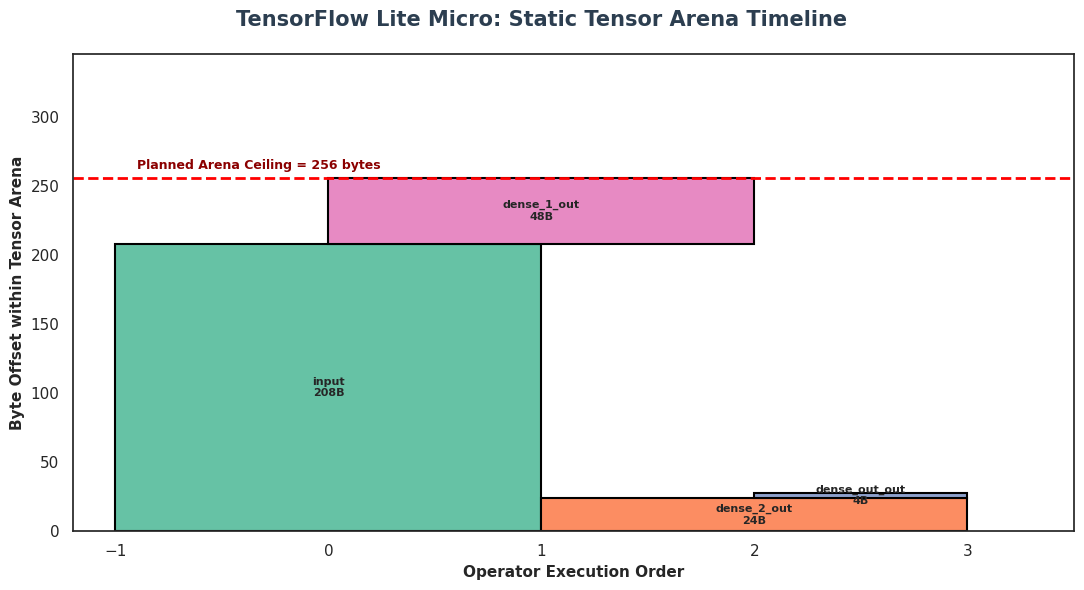

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle("TensorFlow Lite Micro: Static Tensor Arena Timeline", fontsize=15, fontweight='bold', color="#2c3e50")

palette = sns.color_palette("Set2", n_colors=len(placement))
for (name, size, birth, death, offset), c in zip(sorted(placement, key=lambda p: p[4]), palette):
    width = (death - birth + 1)
    ax.add_patch(patches.Rectangle((birth, offset), width, size, facecolor=c, edgecolor="black", lw=1.5))
    ax.text(birth + width / 2, offset + size / 2, f"{name}\n{size}B",
            ha='center', va='center', fontsize=8, fontweight='bold')

ax.axhline(arena_bytes, color="red", ls="--", lw=2)
ax.text(-0.9, arena_bytes + 6, f"Planned Arena Ceiling = {arena_bytes} bytes", color="darkred", fontsize=9, fontweight='bold')

ax.set_xlabel("Operator Execution Order", fontsize=11, fontweight='bold')
ax.set_ylabel("Byte Offset within Tensor Arena", fontsize=11, fontweight='bold')
ax.set_xlim(-1.2, 3.5)
ax.set_ylim(0, arena_bytes * 1.35)
ax.set_xticks(range(-1, 4))
plt.tight_layout()
plt.show()


*(Insight: Each colored bar is one tensor's memory reservation, positioned exactly where the greedy allocator placed it and spanning exactly the operator steps during which it must stay valid. Notice that bars stack vertically only where their horizontal spans overlap -- 'input' and 'dense_1_out' briefly coexist while dense_1 is computing, but once 'input' is fully consumed its row becomes free for a later tensor to reuse. The red ceiling is not a soft target; it is the literal `tensor_arena[]` byte array size an embedded engineer declares in firmware source code, and if any build-time allocation plan exceeds the physical RAM available, the firmware simply fails to link -- there is no graceful degradation on a microcontroller.)*

## Real-World Use Case or Analogy

Think of the TinyML toolchain like **The Submarine Provisioning Problem**:

* **The Microcontroller (The Submarine):** A sealed vessel with a fixed, non-negotiable amount of storage space and power. Unlike a cargo ship (a server) that can resupply at any port, a submarine goes out with everything it will ever have already on board.
* **Flash / ROM (The Hull's Dry Storage):** Bolted-down supplies loaded once before departure -- the model's weights and compiled code. You cannot add more mid-voyage.
* **RAM / The Tensor Arena (The Galley Counter):** A single small workspace where the crew prepares each meal. It is not one counter per dish being cooked simultaneously -- it is one shared counter, cleared and reused between courses.
* **Tensor Lifetimes (Ingredients Prepped Just-in-Time):** A skilled galley crew doesn't lay out every ingredient for every meal of the voyage at once -- they prep an ingredient right before it's needed and clear the counter the moment the dish that used it is plated, freeing space for the next course's prep.
* **The Greedy Allocator (The Head Chef's Prep Schedule):** The chef who decides exactly which counter-space each ingredient gets and when, so the galley never needs a counter bigger than the single busiest moment of any meal -- not the sum of every ingredient across the entire voyage's menu.
* **Edge Impulse Studio (Mission Control's Pre-Departure Simulation):** Before the submarine ever leaves port, mission control runs the entire planned voyage against the known galley counter size and dry-storage capacity, flagging exactly where the plan would run out of space -- so the crew finds out on land, not at depth.

A cloud server can always requisition more memory when it runs low. A submarine -- like a microcontroller -- cannot. The entire discipline of TinyML toolchains exists to plan, down to the byte, a mission that has to work perfectly with only what was loaded before the hatch sealed.